<a href="https://colab.research.google.com/github/taniagoa/Tercer-challenge-CD-Telecom-X-parte2/blob/main/telecomXparte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd
datos=pd.read_csv('/content/datos_tratados.csv')
datos.head()

,IDcliente,evasion,genero,adultoMayor,pareja,dependientes,permanencia,telefonoFijo,MultipleLines,internet,...,DeviceProtection,servicioTecnico,StreamingTV,StreamingMovies,contrato,reciboElectronico,metodoDePago,cargoMensual,cargoTotal,cuentasDiarias
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,5.466667
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,4.991667
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,6.158333
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,8.166667
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,6.991667


Usamos la base de datos obtenida en la primera parte del proyecto

In [50]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   IDcliente          7032 non-null   object 
 1   evasion            7032 non-null   int64  
 2   genero             7032 non-null   object 
 3   adultoMayor        7032 non-null   int64  
 4   pareja             7032 non-null   object 
 5   dependientes       7032 non-null   object 
 6   permanencia        7032 non-null   int64  
 7   telefonoFijo       7032 non-null   object 
 8   MultipleLines      7032 non-null   object 
 9   internet           7032 non-null   object 
 10  OnlineSecurity     7032 non-null   object 
 11  OnlineBackup       7032 non-null   object 
 12  DeviceProtection   7032 non-null   object 
 13  servicioTecnico    7032 non-null   object 
 14  StreamingTV        7032 non-null   object 
 15  StreamingMovies    7032 non-null   object 
 16  contrato           7032 

Teniendo en cuenta los graficos de histograma de la primera parte de telecomX podemos identificar las columnas que no tienen relevancia para evaluar la evasion de clientes, estas columnas seran eliminadas para evitar que afecten al modelo

In [51]:
datos2=datos.drop(columns=['IDcliente','adultoMayor','pareja','dependientes'])
datos2.head()

,evasion,genero,permanencia,telefonoFijo,MultipleLines,internet,OnlineSecurity,OnlineBackup,DeviceProtection,servicioTecnico,StreamingTV,StreamingMovies,contrato,reciboElectronico,metodoDePago,cargoMensual,cargoTotal,cuentasDiarias
0,0,Female,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,5.466667
1,0,Male,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,4.991667
2,1,Male,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,6.158333
3,1,Male,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,8.166667
4,1,Female,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,6.991667


Para los servicios agregados encontramos que la opcion 'No internet service' es redundante con la opcion 'No', asi que aplicamos un reeemplazo.
Para hacer mas sencillo es analisis cambiamos las opciones 'Yes' y 'No' por valores binarios 0 y 1

In [52]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'servicioTecnico', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    datos2[col] = datos2[col].replace({'No internet service': 'No'})

In [53]:
col_codificar=[
     'telefonoFijo','OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'servicioTecnico', 'StreamingTV', 'StreamingMovies','reciboElectronico'
    ]
for col in col_codificar:
  datos2[col]=datos2[col].replace({'No':0,'Yes':1})

/tmp/ipykernel_213/2245886832.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos2[col]=datos2[col].replace({'No':0,'Yes':1})


Matriz de correlacion de variables numericas

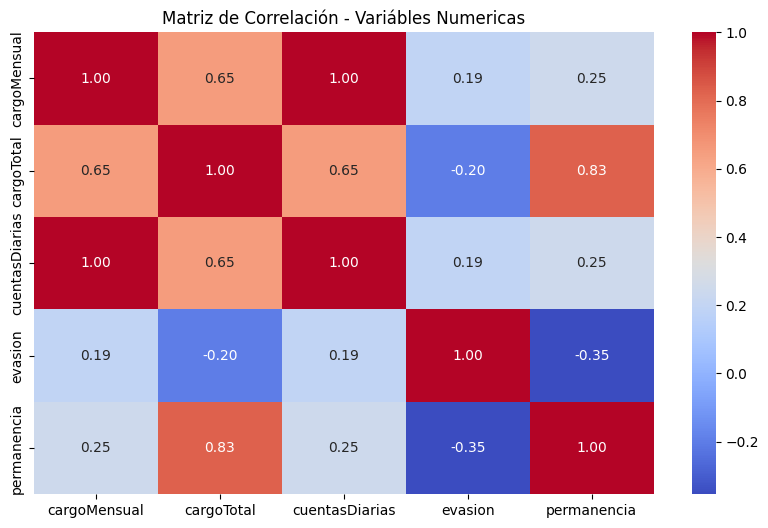

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
df_numeric = datos2.select_dtypes(include="float64")
df_numeric = df_numeric.copy()
df_numeric['evasion'] = datos2['evasion']
df_numeric['permanencia']=datos['permanencia']
corr_matrix = df_numeric.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()

Matriz de correlacion de variables categoricas

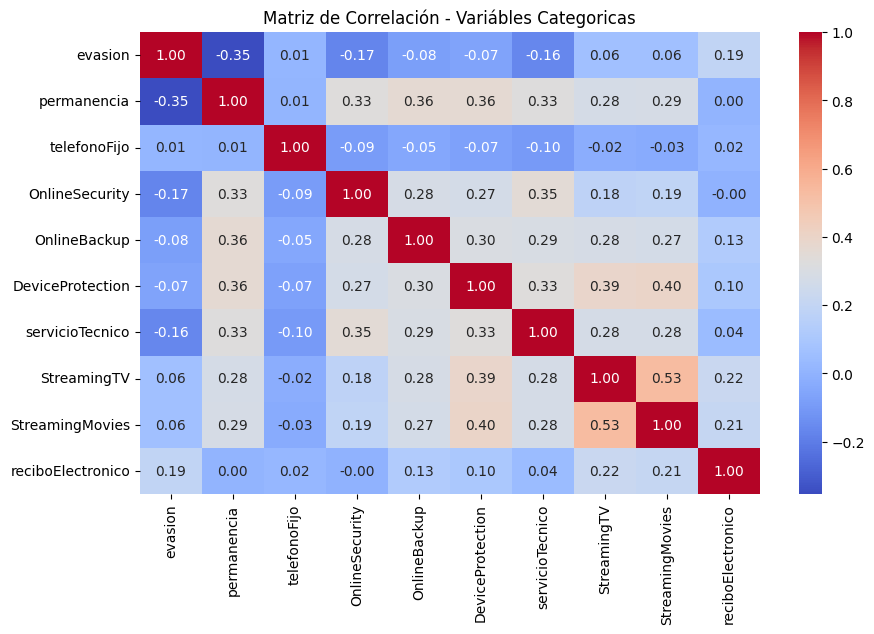

In [55]:
df_numeric = datos2.select_dtypes(include="int64")
corr_matrix = df_numeric.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Categoricas")
plt.show()

Se observa una correlacion debil entre la evasion y las variables numericas, en especial con 'cuentasDiarias' y 'cargoMensual', sin embargo se observa correlacion fuerte entre 'cargoTotal' y 'permanencia', 'cargoTotal' y'cuentasDiarias', 'cargoTotal' y 'cargoMensual', 'cargoMensual' y 'cuentasDiarias' para evitar esa correlacion eliminamos la columna 'cargoTotal' y 'cuentasDiarias'.

La variable que tiene correlacion mas debil con la evasion es 'telefonoFijo', se observa mucha correlacion entre 'StreamingTV' y 'StreamingMovies', eliminamos 'telefonofijo' y 'StreamingMovies'

In [56]:
datos2=datos2.drop(columns=['cargoTotal','cuentasDiarias','telefonoFijo','StreamingMovies'])
datos2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   evasion            7032 non-null   int64  
 1   genero             7032 non-null   object 
 2   permanencia        7032 non-null   int64  
 3   MultipleLines      7032 non-null   object 
 4   internet           7032 non-null   object 
 5   OnlineSecurity     7032 non-null   int64  
 6   OnlineBackup       7032 non-null   int64  
 7   DeviceProtection   7032 non-null   int64  
 8   servicioTecnico    7032 non-null   int64  
 9   StreamingTV        7032 non-null   int64  
 10  contrato           7032 non-null   object 
 11  reciboElectronico  7032 non-null   int64  
 12  metodoDePago       7032 non-null   object 
 13  cargoMensual       7032 non-null   float64
dtypes: float64(1), int64(8), object(5)
memory usage: 769.3+ KB


-el analisis grafico no resulto util

Realizamos la codificacion de variables categoricas que tienen mas de una opcion usando OneHotEncoder

In [57]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
X=datos2.drop('evasion',axis=1)
y=datos2['evasion']
columnas=X.columns
one_hot=make_column_transformer((OneHotEncoder(drop='if_binary'),['genero','internet','contrato','MultipleLines','metodoDePago']),remainder='passthrough',sparse_threshold=0,force_int_remainder_cols=False)
X=one_hot.fit_transform(X)
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__genero_Male', 'onehotencoder__internet_DSL',
       'onehotencoder__internet_Fiber optic',
       'onehotencoder__internet_No',
       'onehotencoder__contrato_Month-to-month',
       'onehotencoder__contrato_One year',
       'onehotencoder__contrato_Two year',
       'onehotencoder__MultipleLines_No',
       'onehotencoder__MultipleLines_No phone service',
       'onehotencoder__MultipleLines_Yes',
       'onehotencoder__metodoDePago_Bank transfer (automatic)',
       'onehotencoder__metodoDePago_Credit card (automatic)',
       'onehotencoder__metodoDePago_Electronic check',
       'onehotencoder__metodoDePago_Mailed check',
       'remainder__permanencia', 'remainder__OnlineSecurity',
       'remainder__OnlineBackup', 'remainder__DeviceProtection',
       'remainder__servicioTecnico', 'remainder__StreamingTV',
       'remainder__reciboElectronico', 'remainder__cargoMensual'],
      dtype=object)

In [58]:
y.value_counts(normalize=True) * 100

,proportion
evasion,
0,73.421502
1,26.578498


Separamos la base de datos en variable dependiente y variables explicativas

In [59]:
X=pd.DataFrame(X,columns=one_hot.get_feature_names_out(columnas))

In [60]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
y=label_encoder.fit_transform(y)

Modelo base de comparación

In [61]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
baseline= DummyClassifier()
baseline.fit(X_train,y_train)
y_pred_dummy=baseline.predict(X_test)
y_pred_dummy


array([0, 0, 0, ..., 0, 0, 0])

In [62]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_dummy))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1554
           1       0.00      0.00      0.00       556

    accuracy                           0.74      2110
   macro avg       0.37      0.50      0.42      2110
weighted avg       0.54      0.74      0.62      2110



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Podemos observar que el modelo base solo predice la clase mayoritaria con una precision de 74% mientras que no logra predecir la clase minoritaria ni una sola vez

Modelo KNN

In [63]:
from sklearn.preprocessing import MinMaxScaler
normalizacion=MinMaxScaler()
X_train_normalizado=normalizacion.fit_transform(X_train)
pd.DataFrame(X_train_normalizado)


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.013930
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.295775,1.0,1.0,0.0,0.0,0.0,0.0,0.631343
2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.802817,1.0,1.0,0.0,0.0,1.0,0.0,0.804975
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.000000,1.0,1.0,1.0,0.0,1.0,0.0,0.819900
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.436620,1.0,0.0,1.0,1.0,1.0,1.0,0.908458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4917,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.591549,1.0,0.0,1.0,1.0,1.0,1.0,0.605970
4918,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.084507,0.0,0.0,1.0,1.0,1.0,0.0,0.458209
4919,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.014085,1.0,0.0,0.0,0.0,0.0,1.0,0.294030
4920,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.746479,1.0,0.0,1.0,1.0,1.0,0.0,0.685075


In [64]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train_normalizado,y_train)
X_test_normalizado=normalizacion.transform(X_test)
y_pred_knn=knn.predict(X_test_normalizado)
y_pred_knn


array([0, 1, 0, ..., 0, 0, 1])

In [65]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1554
           1       0.53      0.52      0.53       556

    accuracy                           0.75      2110
   macro avg       0.68      0.68      0.68      2110
weighted avg       0.75      0.75      0.75      2110



Este modelo tiene un mayor exito al predecir la clase minoritaria pero con un desempeño moderado ya que detecta penas el 52% de los casos de evasion

Modelo Arbol de decisiones

In [66]:
from sklearn.tree import DecisionTreeClassifier
modelo_arbol=DecisionTreeClassifier(max_depth=3,random_state=5)
modelo_arbol.fit(X_train,y_train)
y_pred_tree=modelo_arbol.predict(X_test)
y_pred_tree


array([0, 0, 0, ..., 0, 0, 0])

In [67]:
print(classification_report(y_test,y_pred_tree))

              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1554
           1       0.67      0.40      0.50       556

    accuracy                           0.79      2110
   macro avg       0.74      0.67      0.69      2110
weighted avg       0.78      0.79      0.77      2110



El modelo solo tiene una mejor exactitud global pero solo puede predecir el 40% de los casos de evasion

Modelo Bosque Aleatorio

In [68]:
from sklearn.ensemble import RandomForestClassifier
modelo=RandomForestClassifier(max_depth=5,random_state=42)
modelo.fit(X_train,y_train)
y_pred_rfr=modelo.predict(X_test)
y_pred_rfr


array([0, 0, 0, ..., 0, 0, 1])

In [69]:
print(classification_report(y_test,y_pred_rfr))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1554
           1       0.67      0.50      0.57       556

    accuracy                           0.80      2110
   macro avg       0.75      0.71      0.72      2110
weighted avg       0.79      0.80      0.79      2110



El modelo tiene una exactitud global de 80%, tiene la precision mas alta para la clase positiva pero solo puede predecir el 50% de las evasiones

In [70]:
from sklearn.linear_model import LogisticRegression
modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train, y_train)
y_pred_log = modelo_log.predict(X_test)
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1554
           1       0.65      0.57      0.60       556

    accuracy                           0.80      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.80      0.80      2110



Este modelo es el que hace una mejor prediccion tanto de las clases positivas y negativas, logrando una prediccion de 57% de evasiones, pero aun hay un desbalance

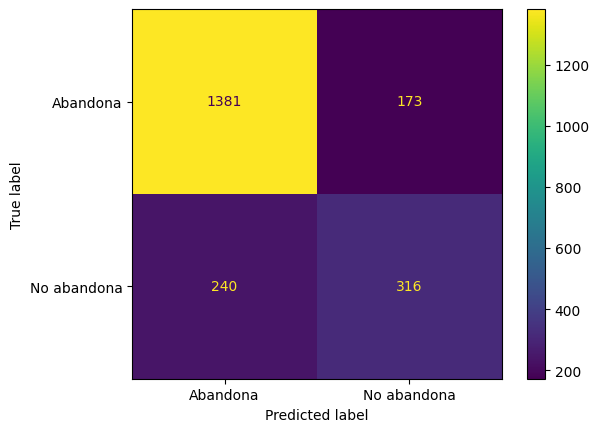

In [71]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
matriz_confusion=confusion_matrix(y_test,y_pred_log)
visualizacion=ConfusionMatrixDisplay( confusion_matrix=matriz_confusion,display_labels=['Abandona','No abandona'])
visualizacion.plot();

Balanceamos usando los hiperparametros de LogisticRegression

In [72]:
modelo_log = LogisticRegression(max_iter=1000, class_weight="balanced")
modelo_log.fit(X_train, y_train)
y_pred_log_balance = modelo_log.predict(X_test)
print(classification_report(y_test, y_pred_log_balance))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1554
           1       0.50      0.79      0.61       556

    accuracy                           0.74      2110
   macro avg       0.70      0.75      0.71      2110
weighted avg       0.80      0.74      0.75      2110



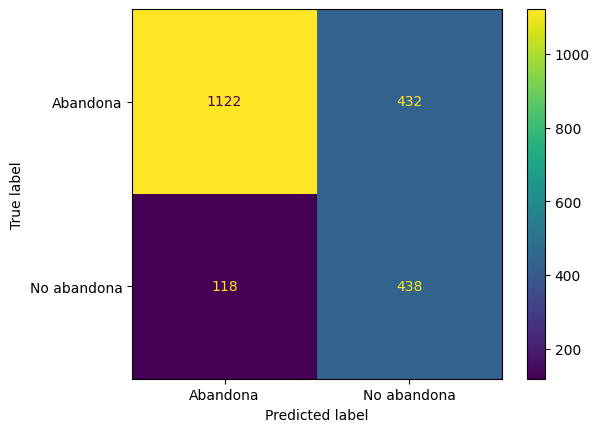

In [73]:
matriz_confusion=confusion_matrix(y_test,y_pred_log_balance)
visualizacion=ConfusionMatrixDisplay( confusion_matrix=matriz_confusion,display_labels=['Abandona','No abandona'])
visualizacion.plot();

Analisis de las variables mas relevantes para la prediccion de la cancelacion en el modelo que tuvo el mejor desempeño


In [75]:
import numpy as np

logreg = LogisticRegression(class_weight="balanced", max_iter=1000)
logreg.fit(X_train, y_train)

coef = logreg.coef_[0]
variables = X_train.columns

# Tabla con odds ratios
results = pd.DataFrame({
    "Variable": variables,
    "Coeficiente": coef,
    "Odds Ratio": np.exp(coef)
}).sort_values(by="Odds Ratio", ascending=False)

print(results)


                                             Variable  Coeficiente  Odds Ratio
4              onehotencoder__contrato_Month-to-month     0.666158    1.946743
8       onehotencoder__MultipleLines_No phone service     0.496921    1.643653
20                       remainder__reciboElectronico     0.345458    1.412637
12       onehotencoder__metodoDePago_Electronic check     0.179188    1.196245
2                 onehotencoder__internet_Fiber optic     0.138121    1.148115
19                             remainder__StreamingTV     0.077367    1.080438
21                            remainder__cargoMensual     0.024288    1.024585
14                             remainder__permanencia    -0.031781    0.968719
0                          onehotencoder__genero_Male    -0.052212    0.949127
17                        remainder__DeviceProtection    -0.076424    0.926423
13           onehotencoder__metodoDePago_Mailed check    -0.140089    0.869281
5                    onehotencoder__contrato_One yea

Variables Positivas
- Contrato Month-to-month (β=0.66, OR≈1.95):los clientes con contrato mensual tienen casi el doble de probabilidad de cancelar.
- No tener servicio de teléfono (β=0.49, OR≈1.64):aumenta el riesgo de evasion, quizá porque refleja menor compromiso con el servicio.
- Recibo electrónico (β=0.34, OR≈1.41):quienes usan factura electrónica muestran mayor probabilidad de cancelar.
- Pago con Electronic check (β=0.18, OR≈1.19):también incrementa el riesgo, aunque en menor medida.
- Internet Fiber optic (β=0.13, OR≈1.15):los clientes con fibra tienen más riesgo de churn que los de DSL.
Otras variables con coeficiente positivo como servicio de Streaming o cargo mensual tienen poca influencia



Variables negativas
- Permanencia (β=-0.03, OR≈0.97):a mayor tiempo de permanencia, menor probabilidad de cancelar.
- Contrato One year (β=-0.14, OR≈0.86) y Two year (β=-0.98, OR≈0.37): contratos largos protegen fuertemente contra evasion.
- Internet DSL (β=-0.20, OR≈0.81):clientes con DSL tienen menor riesgo que los de fibra.
- Servicios adicionales: OnlineBackup (OR≈0.81), DeviceProtection (OR≈0.92), OnlineSecurity (OR≈0.62), Servicio técnico (OR≈0.65):Todos reducen la probabilidad de churn.
- Métodos de pago automáticos (Bank transfer, Credit card):coeficientes negativos, sugieren que quienes pagan automáticamente tienen menor riesgo de cancelar.
- MultipleLines (Yes o No) :ambos con coeficientes negativos,indica que tener multiples lineas no influye en la **evasion**


# Informe Final
- Modelos iniciales (Dummy, KNN): mostraron buen desempeño en la prediccion de clase mayoritaria(0=no evaden) pero bajo recall en la minoritaria(1=evaden).
- Modelos Arbol de Decisiones y RandomForest: mejoraron el recall de la clase 1 (evaden), aunque sacrificaron algo de precisión en la clase 0 y exactitud global.
- Logistic Regression con class_weight="balanced": es el modelo con mejor recall en la clase 1, tambien disminuyo la precision  en la clase 0 y exactitud global
- Trade-off observado: aumentar recall en la evasion implica perder algo de precisión en la clase 0, pero es más valioso para el negocio porque permite identificar clientes en riesgo
- Las variables que incrementan la probabilidad de evasion (Factores de Riesgo)son principalmente: tener contratos mensuales, no adquirir linea telefonica y usar el pago electronico. Estos factores pueden indicar menos compromiso del cliente.
- Las variables que disminuyen la probabilidad de evasion (Factores Protectores) son principalmente: contratos largos con mayor tiempo de permanecia, contratar servicios adicionales y usar como metodo de pago transferencias bancarias o tarjetas de credito



# Estrategias de retencion basadas en los resultados
Incentivar contratos de mayor duración
- Ofrecer descuentos o beneficios exclusivos para clientes que migren de contratos mensuales a anuales o bianuales.
- Estrategia: campañas de fidelización con beneficios acumulativos.

Promover métodos de pago automáticos
- Bonificaciones o descuentos por usar débito automático o tarjeta de crédito.
- Estrategia: simplificar la experiencia de pago y reducir fricción.

Fortalecer servicios adicionales
- Paquetes de seguridad, respaldo y soporte técnico como valor agregado.
- Estrategia: mostrar cómo estos servicios protegen y facilitan la vida del cliente.
